# Class Lab: Discerning A Simplified Latent Structure From Your Data'

## Step 1: setup goal
- explain the subjective “wine quality” feedback using the different wine properties. 
- use Principal Component Analysis (PCA) to find latent variables in a wine quality data set.
- compare how well a set of latent variables works in predicting the quality of wine against the original observable set. 

## Step 2: retrieve data
- data source: https://archive.ics.uci.edu/static/public/186/wine+quality.zip
- It’s 1,599 rows and 12 columns.
- Principal Component Analysis: a technique to find the latent variables in data set while retaining as much information as possible.

<img src="../../file/image/tbl3_2.png" width="500">


In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df_wine = pd.read_csv(url, sep= ";")

## Step 3: prepare data

1. Separate data set into features variables (X) and target variable (y)
2. Standardizes all the features in X so they are on the same scale (mean = 0, variance = 1). <br>
   This prevents features with larger numeric ranges (like “total sulfur dioxide”) from dominating smaller ones (like “sulphates”).<br>
   z = (x-μ)/σ

In [3]:
# y is a vector (series) and represents the target variable of wine quality.
y = df_wine['quality']

# X is a matrix (data frame) of features variables. These features are wine properties such as density and alcohol presence.
X = df_wine[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']]

# standardizes all the features in X, X is a ndarray now
X_scaled = preprocessing.StandardScaler().fit(X).transform(X)
X_scaled[0:3]

array([[-0.52835961,  0.96187667, -1.39147228, -0.45321841, -0.24370669,
        -0.46619252, -0.37913269,  0.55827446,  1.28864292, -0.57920652,
        -0.96024611],
       [-0.29854743,  1.96744245, -1.39147228,  0.04341614,  0.2238752 ,
         0.87263823,  0.62436323,  0.02826077, -0.7199333 ,  0.1289504 ,
        -0.58477711],
       [-0.29854743,  1.29706527, -1.18607043, -0.16942723,  0.09635286,
        -0.08366945,  0.22904665,  0.13426351, -0.33117661, -0.04808883,
        -0.58477711]])

## Step 4: explore data

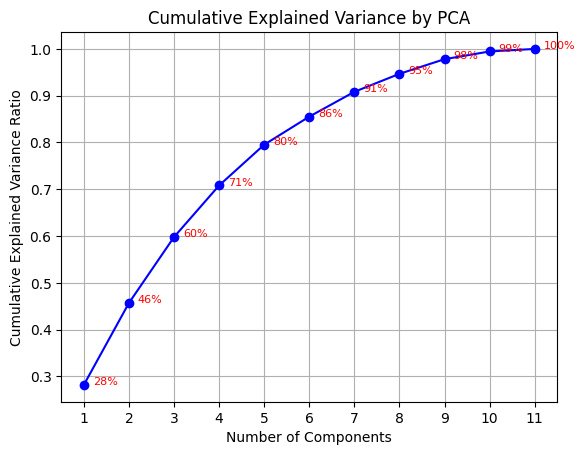

In [4]:
# explore data from dimension reduction perspective by PCA
pca = PCA()
pca_model = pca.fit(X_scaled)
X_projected = pca_model.transform(X_scaled)
# plt.plot(pca_model.explained_variance_, marker='o', linestyle='-', color='b')

# cumulative explained variance
cumulative_var = np.cumsum(pca_model.explained_variance_ratio_)

plt.plot(cumulative_var, marker='o', linestyle='-', color='b')

for i, val in enumerate(cumulative_var):
    plt.text(i + 0.2, val, f'{val:.0%}', fontsize=8, color='r')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.xticks(np.arange(len(cumulative_var)), np.arange(1, len(cumulative_var) + 1))

plt.title("Cumulative Explained Variance by PCA")
plt.grid(True)
plt.show()

In [5]:
# illustrate how latent variables are constructed
latent_vars = pd.DataFrame(pca_model.components_, columns=list(['fixed acidity', 'volatile acidity', 'citric acid',\
                                                 'residual sugar','chlorides', 'free sulfur dioxide',\
                                                 'total sulfur dioxide', 'density','pH',\
                                                 'sulphates', 'alcohol']))
latent_vars.round(2).head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.49,-0.24,0.46,0.15,0.21,-0.04,0.02,0.40,-0.44,0.24,-0.11
1,-0.11,0.27,-0.15,0.27,0.15,0.51,0.57,0.23,0.01,-0.04,-0.39
2,-0.12,-0.45,0.24,0.10,-0.09,0.43,0.32,-0.34,0.06,0.28,0.47
3,-0.23,0.08,-0.08,-0.37,0.67,-0.04,-0.03,-0.17,-0.00,0.55,-0.12
4,-0.08,0.22,-0.06,0.73,0.25,-0.16,-0.22,0.16,0.27,0.23,0.35


In [6]:
# Customize the row indices with letters
latent_var_names = ['PC1_Persistent acidity', 'PC2_Sulfides', 'PC3_Volatile acidity', 'PC4_Chlorides', 'PC5_Lack of residual sugar']
top_5_latent_vars = latent_vars.iloc[:5, :]
top_5_latent_vars.index = latent_var_names
top_5_latent_vars.round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
PC1_Persistent acidity,0.49,-0.24,0.46,0.15,0.21,-0.04,0.02,0.40,-0.44,0.24,-0.11
PC2_Sulfides,-0.11,0.27,-0.15,0.27,0.15,0.51,0.57,0.23,0.01,-0.04,-0.39
PC3_Volatile acidity,-0.12,-0.45,0.24,0.10,-0.09,0.43,0.32,-0.34,0.06,0.28,0.47
PC4_Chlorides,-0.23,0.08,-0.08,-0.37,0.67,-0.04,-0.03,-0.17,-0.00,0.55,-0.12
PC5_Lack of residual sugar,-0.08,0.22,-0.06,0.73,0.25,-0.16,-0.22,0.16,0.27,0.23,0.35


## Step 3: prepare data again (top-5 PCA components)

In [7]:
# transform raw data into the result of dimensionality reduction after PCA
X_projected_df = pd.DataFrame(X_projected).iloc[:,:5]
X_projected_df.columns = latent_var_names
X_projected_df.head().round(2)

,PC1_Persistent acidity,PC2_Sulfides,PC3_Volatile acidity,PC4_Chlorides,PC5_Lack of residual sugar
0,-1.62,0.45,-1.77,0.04,0.07
1,-0.80,1.86,-0.91,0.55,-0.02
2,-0.75,0.88,-1.17,0.41,-0.04
3,2.36,-0.27,0.24,-0.93,-1.50
4,-1.62,0.45,-1.77,0.04,0.07


## Step 5: build model
Comparing the accuracy of the original data set with latent variables

In [8]:
# Wine score prediction before principal component analysis
from sklearn.datasets import load_digits
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score)
import matplotlib.pyplot as plt
import math

gnb = GaussianNB()
gnb.fit(X_scaled, y)

# test model
y_pred = gnb.predict(X_scaled)

# validate model - accuracy and confusion_matrix
acc = accuracy_score(y, y_pred)
print(f"Accuracy: {acc:2f} \n")

print(confusion_matrix(y, y_pred),'\n')
print('# of correct predictions:', confusion_matrix(y, y_pred).trace(),'\n') # sum of diagonal elements

Accuracy: 0.560976 

[[  3   2   4   1   0   0]
 [  1   8  29  13   1   1]
 [  4  26 456 171  24   0]
 [  0  19 185 318 111   5]
 [  0   1  12  74 110   2]
 [  0   0   0   5  11   2]] 

# of correct predictions: 897 



In [9]:
# Wine score prediction with top-5 principal components
pca = PCA(n_components= 5)
pca_model = pca.fit(X_scaled)
X_projected = pca_model.transform(X_scaled)

gnb = GaussianNB()
gnb.fit(X_projected, y)

# test model
y_pred = gnb.predict(X_projected)

# validate model - accuracy and confusion_matrix
acc = accuracy_score(y, y_pred)
print(f"Accuracy: {acc:2f} \n")

print(confusion_matrix(y, y_pred),'\n')
print('# of correct predictions:', confusion_matrix(y, y_pred).trace(),'\n') # sum of diagonal elements

Accuracy: 0.565353 

[[  4   0   5   1   0   0]
 [  1   2  27  22   1   0]
 [  2  15 445 216   3   0]
 [  0  10 184 403  41   0]
 [  0   2   8 139  50   0]
 [  0   0   0  10   8   0]] 

# of correct predictions: 904 



## Step 6: presentation

[712]
[712, 816]
[712, 816, 903]
[712, 816, 903, 893]
[712, 816, 903, 893, 904]
[712, 816, 903, 893, 904, 920]
[712, 816, 903, 893, 904, 920, 930]
[712, 816, 903, 893, 904, 920, 930, 927]
[712, 816, 903, 893, 904, 920, 930, 927, 937]


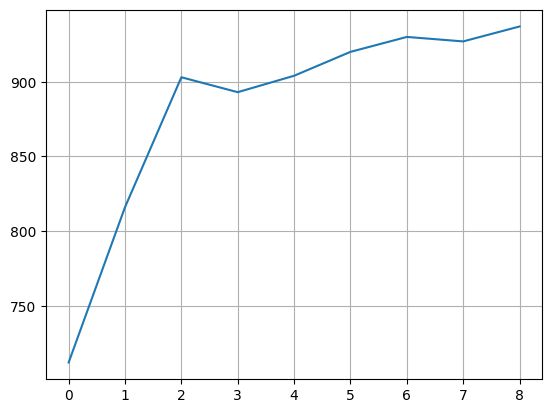

In [10]:
gnb = GaussianNB()
predicted_correct = []
for i in range(1,10):
    pca = PCA(n_components= i)
    pca_model = pca.fit(X_scaled)
    X_projected = pca_model.transform(X_scaled)
    gnb.fit(X_projected, y)

    # test model
    y_pred = gnb.predict(X_projected)
    predicted_correct.append(confusion_matrix(y, y_pred).trace())
    print(list(map(int,predicted_correct)))
plt.plot(predicted_correct)
plt.grid()
plt.show()          